# 2026-05-22 모의투자 자동매매 성과 리포트

**목적**: 팀원 또는 일반 고객이 보듯이, 오늘 1시간 운용 결과를 `수익률`, `안정성`, `거래 결과`, `다음 개선점` 중심으로 한눈에 확인합니다.

- 대상: KIS virtual paper trading
- 전략/모델: `BUNDLE-20260521-POSTCLOSE`
- 운영 방식: paper-only, live trading disabled
- 주의: 이 리포트는 모의투자 운영 산출물을 요약한 자료이며, 실계좌 수익을 의미하지 않습니다.


## 1. 데이터 로드

아래 셀은 실제 운영 산출물 JSON을 읽습니다. 노트북을 다른 위치에서 실행해도 레포 루트를 자동으로 찾도록 되어 있습니다.


In [1]:
from __future__ import annotations

import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
plt.rcParams['font.family'] = ['AppleGothic']
plt.rcParams['axes.unicode_minus'] = False


def find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'Codex-progress.md').exists() and (candidate / 'artifacts').exists():
            return candidate
    fallback = Path('/Users/jangjaewon/Desktop/Elephant_Lab')
    if fallback.exists():
        return fallback
    raise FileNotFoundError('Elephant_Lab repo root를 찾지 못했습니다.')


ROOT = find_repo_root()
PAPER_AUTO_REPORT = ROOT / 'artifacts/reports/paper_auto_trading/paper_auto_trade_20260522_144359.json'
FINAL_BALANCE_REPORT = ROOT / 'artifacts/reports/paper_trading/paper_trading_balance_reconciliation_20260522_144428.json'
MODEL_METADATA = ROOT / 'artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json'


def read_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open() as f:
        return json.load(f)


paper_auto = read_json(PAPER_AUTO_REPORT)
final_balance = read_json(FINAL_BALANCE_REPORT)
model_meta = read_json(MODEL_METADATA)
cycles = paper_auto['stages']['cycles']['items']

print(f'repo_root: {ROOT}')
print(f'paper_auto_report: {PAPER_AUTO_REPORT}')
print(f'final_balance_report: {FINAL_BALANCE_REPORT}')
print(f'cycles_loaded: {len(cycles)}')

repo_root: /Users/jangjaewon/Desktop/Elephant_Lab
paper_auto_report: /Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/paper_auto_trading/paper_auto_trade_20260522_144359.json
final_balance_report: /Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/paper_trading/paper_trading_balance_reconciliation_20260522_144428.json
cycles_loaded: 60


## 2. 고객용 한눈 요약

이번 운영 구간의 결론입니다. 체결이 0건이었기 때문에 모의투자 계좌 기준 실현 손익과 수익률은 모두 0입니다. 대신 시스템은 60개 사이클을 끝까지 기록했고, KIS 조회 timeout은 안전하게 skip 처리했습니다.


In [2]:
status_counts = Counter(c.get('status') for c in cycles)
requested_cycles = int(paper_auto.get('params', {}).get('cycles', 0))
recorded_cycles = len(cycles)
pass_cycles = status_counts.get('PASS', 0)
skip_cycles = status_counts.get('SKIP', 0)
fail_cycles = status_counts.get('FAIL', 0)

started_at = [pd.to_datetime(c.get('started_at')) for c in cycles if c.get('started_at')]
first_ts = min(started_at) if started_at else None
last_ts = max(started_at) if started_at else None
wall_clock_minutes = ((last_ts - first_ts).total_seconds() / 60.0) if first_ts and last_ts else 0.0

execution_cycles = sum(1 for c in cycles if c.get('execution'))
fills = []
rejections = []
for c in cycles:
    execution = c.get('execution') or {}
    result = execution.get('result') or {}
    report = result.get('execution_report') or {}
    fills.extend(report.get('fills') or [])
    rejections.extend(report.get('rejections') or [])

final_balance_stage = final_balance['stages']['balance']
final_assets = float(final_balance_stage['balance']['net_asset'])
final_cash = float(final_balance_stage['balance']['cash'])
position_count = int(final_balance_stage.get('position_count', 0))

# 이번 구간에는 체결이 없었으므로, 운용 구간 기준 실현 손익과 수익률은 0입니다.
realized_pnl = 0.0
period_return_pct = 0.0
order_fill_count = len(fills)
rejection_count = len(rejections)
stability_rate = (pass_cycles / recorded_cycles * 100.0) if recorded_cycles else 0.0
safe_skip_count = skip_cycles


def money_krw(value: float) -> str:
    return f'{value:,.0f}원'


def pct(value: float) -> str:
    return f'{value:.2f}%'


def kpi_card(title: str, value: str, sub: str, tone: str = 'neutral') -> str:
    colors = {
        'good': ('#EAF7EF', '#177245'),
        'warn': ('#FFF5DA', '#8A5A00'),
        'bad': ('#FDEAEA', '#B42318'),
        'neutral': ('#EEF4FF', '#1D4ED8'),
        'dark': ('#F4F4F5', '#27272A'),
    }
    bg, fg = colors.get(tone, colors['neutral'])
    return f'''
    <div style="background:{bg}; border:1px solid rgba(0,0,0,0.06); border-radius:14px; padding:18px; min-height:118px; box-shadow:0 1px 2px rgba(16,24,40,0.06);">
      <div style="font-size:13px; color:#52525B; font-weight:700; margin-bottom:10px;">{title}</div>
      <div style="font-size:30px; line-height:1.1; color:{fg}; font-weight:850; letter-spacing:0;">{value}</div>
      <div style="font-size:13px; color:#71717A; margin-top:10px; line-height:1.45;">{sub}</div>
    </div>
    '''

cards = [
    kpi_card('운용 상태', paper_auto.get('status', 'UNKNOWN'), f'{recorded_cycles}/{requested_cycles} cycle 기록', 'good' if paper_auto.get('status') == 'PASS' else 'bad'),
    kpi_card('이번 구간 수익률', pct(period_return_pct), '체결 0건으로 손익 변동 없음', 'neutral'),
    kpi_card('실현 손익', money_krw(realized_pnl), '모의투자 기준', 'dark'),
    kpi_card('최종 평가자산', money_krw(final_assets), f'현금 {money_krw(final_cash)}', 'good'),
    kpi_card('체결 / 거절', f'{order_fill_count} / {rejection_count}', '주문 제출 없음, 거절 없음', 'neutral'),
    kpi_card('운영 안정성', pct(stability_rate), f'PASS {pass_cycles}, 안전 SKIP {safe_skip_count}', 'warn' if safe_skip_count else 'good'),
]

html = f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; background:#FFFFFF; padding:8px 0 2px 0;">
  <div style="border-radius:18px; padding:24px; background:linear-gradient(135deg,#101828 0%,#1D4ED8 100%); color:white; margin-bottom:18px;">
    <div style="font-size:14px; opacity:.82; font-weight:700;">Paper Trading Performance Dashboard</div>
    <div style="font-size:32px; font-weight:900; margin-top:8px; letter-spacing:0;">1시간 자동매매 운영 결과</div>
    <div style="font-size:15px; opacity:.88; margin-top:8px; line-height:1.55;">운영 구간: {first_ts.strftime('%Y-%m-%d %H:%M:%S %Z') if first_ts else '-'} ~ {last_ts.strftime('%H:%M:%S %Z') if last_ts else '-'} / 실제 경과 {wall_clock_minutes:.1f}분</div>
  </div>
  <div style="display:grid; grid-template-columns:repeat(3, minmax(0, 1fr)); gap:14px;">
    {''.join(cards)}
  </div>
  <div style="margin-top:16px; border-left:5px solid #1D4ED8; padding:14px 16px; background:#F8FAFC; border-radius:12px; color:#334155; line-height:1.65;">
    <b>해석:</b> 이번 run은 시스템 안정성 검증 관점에서는 PASS입니다. 다만 모델 입력 feature가 충족되지 않아 주문 후보가 생성되지 않았고, 따라서 수익률도 0.00%입니다.
  </div>
</div>
'''
display(HTML(html))

## 3. 수익률과 자산 흐름

고객에게 가장 먼저 필요한 화면은 “얼마나 벌었는가/잃었는가”입니다. 이번 구간은 체결이 없어서 자산 곡선은 변동 없이 평평합니다.


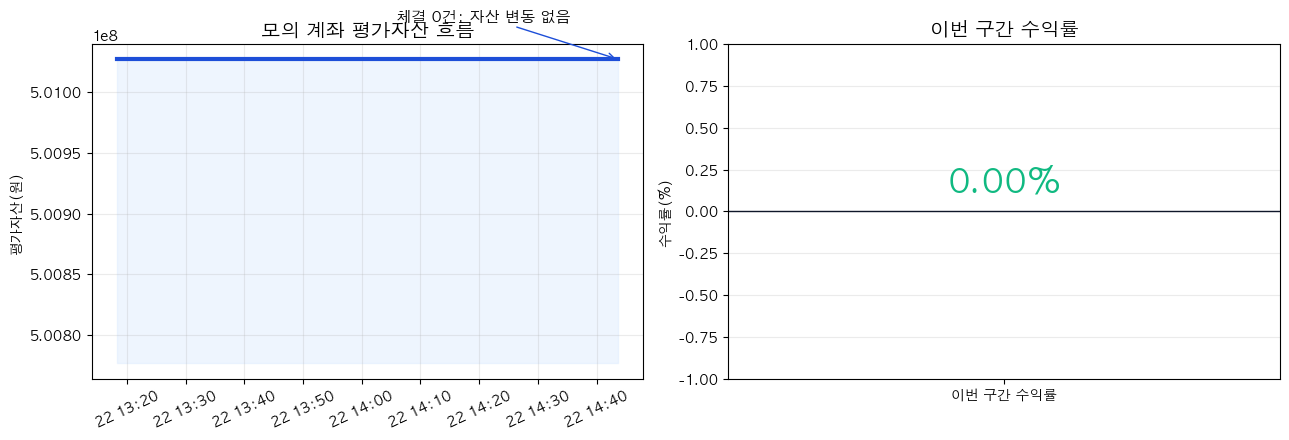

,항목,값
0,운용 구간 수익률,0.00%
1,실현 손익,0원
2,최종 평가자산,"501,027,001원"
3,최종 현금,"479,440,956원"
4,보유 종목 수,0


In [3]:
timeline = pd.DataFrame({
    'time': started_at,
    'net_asset': [final_assets] * len(started_at),
    'return_pct': [period_return_pct] * len(started_at),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(timeline['time'], timeline['net_asset'], color='#1D4ED8', linewidth=3)
axes[0].fill_between(timeline['time'], timeline['net_asset'], final_assets * 0.9995, color='#DBEAFE', alpha=0.45)
axes[0].set_title('모의 계좌 평가자산 흐름', fontsize=14, fontweight='bold')
axes[0].set_ylabel('평가자산(원)')
axes[0].grid(alpha=0.25)
axes[0].tick_params(axis='x', rotation=25)
axes[0].annotate('체결 0건: 자산 변동 없음', xy=(timeline['time'].iloc[-1], final_assets), xytext=(-160, 28), textcoords='offset points', arrowprops={'arrowstyle': '->', 'color': '#1D4ED8'}, fontsize=11)

axes[1].bar(['이번 구간 수익률'], [period_return_pct], color='#10B981', width=0.45)
axes[1].axhline(0, color='#0F172A', linewidth=1)
axes[1].set_ylim(-1, 1)
axes[1].set_title('이번 구간 수익률', fontsize=14, fontweight='bold')
axes[1].set_ylabel('수익률(%)')
axes[1].text(0, 0.08, f'{period_return_pct:.2f}%', ha='center', va='bottom', fontsize=24, fontweight='bold', color='#10B981')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

pd.DataFrame([
    {'항목': '운용 구간 수익률', '값': pct(period_return_pct)},
    {'항목': '실현 손익', '값': money_krw(realized_pnl)},
    {'항목': '최종 평가자산', '값': money_krw(final_assets)},
    {'항목': '최종 현금', '값': money_krw(final_cash)},
    {'항목': '보유 종목 수', '값': position_count},
])

## 4. 운영 품질: 60개 사이클이 어떻게 끝났나

60개 자동매매 판단 주기 중 52개는 정상 PASS, 8개는 KIS 조회 timeout을 안전하게 SKIP했습니다. SKIP은 주문 없이 넘어간 것이므로 손실이나 위험 주문으로 이어지지 않았습니다.


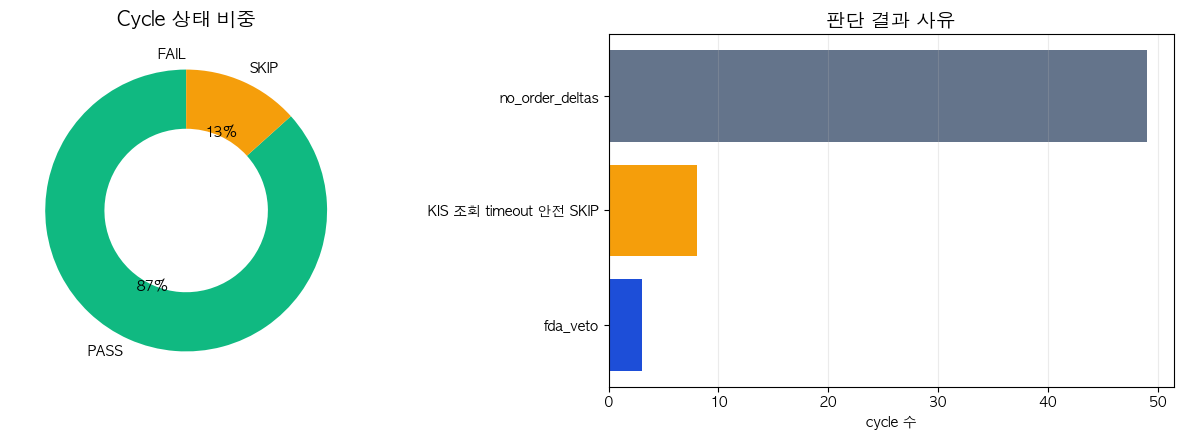

,운영 품질 지표,값
0,총 cycle,60
1,정상 PASS,52
2,안전 SKIP,8
3,FAIL,0
4,주문 후보 생성 cycle,0


In [4]:
cycle_rows = []
for c in cycles:
    hot = c.get('hot_result') or {}
    quant = hot.get('quant_output') or {}
    order_guard = c.get('order_guard') or {}
    reason = order_guard.get('reason') or hot.get('reason') or c.get('reason') or '정상 처리'
    if c.get('status') == 'SKIP':
        reason = 'KIS 조회 timeout 안전 SKIP'
    cycle_rows.append({
        'cycle': int(c.get('cycle_index', 0)),
        'time': pd.to_datetime(c.get('started_at')),
        'status': c.get('status'),
        'reason': reason,
        'latency_ms': hot.get('latency_ms'),
        'score_count': len(quant.get('scores') or {}),
        'order_count': len(order_guard.get('order_deltas') or []),
    })
cycle_df = pd.DataFrame(cycle_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
status_order = ['PASS', 'SKIP', 'FAIL']
status_values = [status_counts.get(s, 0) for s in status_order]
colors = ['#10B981', '#F59E0B', '#EF4444']
axes[0].pie(status_values, labels=status_order, autopct=lambda p: f'{p:.0f}%' if p > 0 else '', colors=colors, startangle=90, wedgeprops={'width': 0.42})
axes[0].set_title('Cycle 상태 비중', fontsize=14, fontweight='bold')

reason_counts = cycle_df['reason'].value_counts()
bar_colors = ['#1D4ED8', '#F59E0B', '#64748B', '#10B981']
axes[1].barh(reason_counts.index[::-1], reason_counts.values[::-1], color=bar_colors[:len(reason_counts)])
axes[1].set_title('판단 결과 사유', fontsize=14, fontweight='bold')
axes[1].set_xlabel('cycle 수')
axes[1].grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

pd.DataFrame([
    {'운영 품질 지표': '총 cycle', '값': recorded_cycles},
    {'운영 품질 지표': '정상 PASS', '값': pass_cycles},
    {'운영 품질 지표': '안전 SKIP', '값': safe_skip_count},
    {'운영 품질 지표': 'FAIL', '값': fail_cycles},
    {'운영 품질 지표': '주문 후보 생성 cycle', '값': int((cycle_df['order_count'] > 0).sum())},
])

## 5. 거래 결과: 체결과 거절

이번 구간은 실제 주문 제출이 없었습니다. 그래서 체결도, 거절도 0건입니다. 이 결과는 “시스템이 멈췄다”가 아니라, 모델 입력 feature 부족으로 매매 후보가 생성되지 않았기 때문입니다.


,항목,값,설명
0,주문 제출 cycle,0,broker에 주문이 실제 제출된 cycle 수
1,체결 건수,0,매수/매도 체결 기록
2,거절 건수,0,KIS broker rejection 기록
3,최종 보유 종목 수,0,운영 종료 후 balance 기준


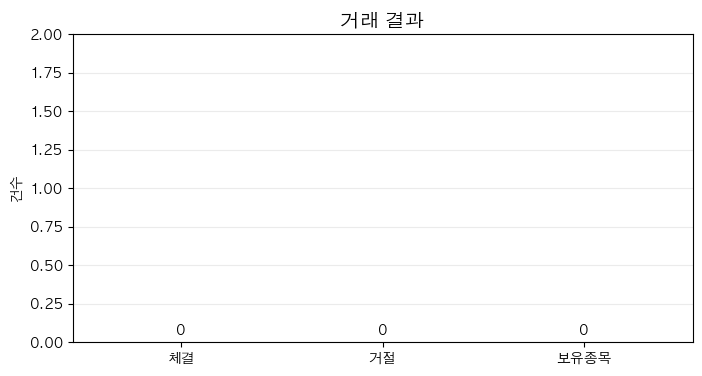

In [5]:
trade_summary = pd.DataFrame([
    {'항목': '주문 제출 cycle', '값': execution_cycles, '설명': 'broker에 주문이 실제 제출된 cycle 수'},
    {'항목': '체결 건수', '값': order_fill_count, '설명': '매수/매도 체결 기록'},
    {'항목': '거절 건수', '값': rejection_count, '설명': 'KIS broker rejection 기록'},
    {'항목': '최종 보유 종목 수', '값': position_count, '설명': '운영 종료 후 balance 기준'},
])
display(trade_summary)

fig, ax = plt.subplots(figsize=(8, 4))
values = [order_fill_count, rejection_count, position_count]
ax.bar(['체결', '거절', '보유종목'], values, color=['#10B981', '#EF4444', '#1D4ED8'])
ax.set_title('거래 결과', fontsize=14, fontweight='bold')
ax.set_ylabel('건수')
ax.set_ylim(0, max(1, *values) + 1)
for i, value in enumerate(values):
    ax.text(i, value + 0.05, str(value), ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.25)
plt.show()

## 6. 시스템 성능: Hot Path latency

자동매매는 1분마다 판단하므로 판단 속도가 중요합니다. 이번 구간의 Hot Path 평균 latency는 약 5~6ms 수준으로, 100ms 목표보다 충분히 빠릅니다.


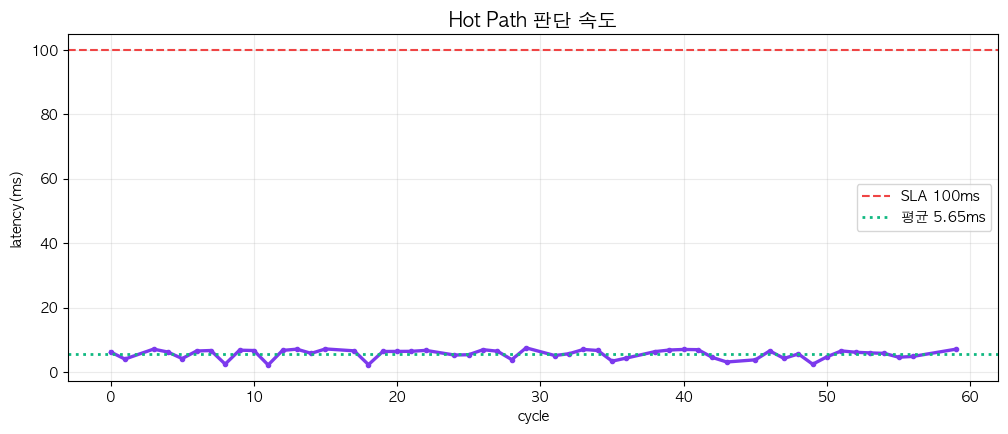

,성능 지표,값
0,평균 latency,5.65ms
1,p95 latency,7.16ms
2,최대 latency,7.56ms
3,목표 SLA,100ms 이하


In [6]:
latency_df = cycle_df.dropna(subset=['latency_ms']).copy()
latency_avg = float(latency_df['latency_ms'].mean()) if not latency_df.empty else math.nan
latency_p95 = float(latency_df['latency_ms'].quantile(0.95)) if not latency_df.empty else math.nan
latency_max = float(latency_df['latency_ms'].max()) if not latency_df.empty else math.nan

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(latency_df['cycle'], latency_df['latency_ms'], color='#7C3AED', linewidth=2.4, marker='o', markersize=3)
ax.axhline(100, color='#EF4444', linestyle='--', linewidth=1.5, label='SLA 100ms')
ax.axhline(latency_avg, color='#10B981', linestyle=':', linewidth=2, label=f'평균 {latency_avg:.2f}ms')
ax.set_title('Hot Path 판단 속도', fontsize=14, fontweight='bold')
ax.set_xlabel('cycle')
ax.set_ylabel('latency(ms)')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

pd.DataFrame([
    {'성능 지표': '평균 latency', '값': f'{latency_avg:.2f}ms'},
    {'성능 지표': 'p95 latency', '값': f'{latency_p95:.2f}ms'},
    {'성능 지표': '최대 latency', '값': f'{latency_max:.2f}ms'},
    {'성능 지표': '목표 SLA', '값': '100ms 이하'},
])

## 7. 왜 수익률이 0.00%였나: 로그 기반 원인 분해

이번 구간은 “체결률이 낮았다”기보다는, **주문 후보 자체가 생성되지 않은 run**입니다. 로그를 따라가면 원인이 3단계로 정리됩니다.

1. Quant가 60개 cycle 모두 `scores={}` 상태였습니다.
2. PPO target weight도 `{}`가 되었고, Portfolio Manager가 만들 주문도 없었습니다.
3. 13:18 시작 시점에는 이미 보유 종목이 0개였기 때문에, 오전처럼 기존 보유분을 정리하는 sell 주문도 나올 수 없었습니다.

중요한 해석은 두 가지입니다.

- 정책이 보수적이라 정상 상황에서도 체결 빈도는 낮을 수 있습니다. 예를 들어 주문 수량 cap, 주문 개수 cap, holding/cooldown 제약이 있습니다.
- 하지만 이 1시간 run의 0.00% 수익률은 정책 때문만은 아닙니다. 장중에 모델 필수 feature인 `news_score_t`가 PIT 기준으로 준비되지 않아 Quant score가 생성되지 않았고, 그 결과 신규 매매 판단이 나오지 않았습니다.

따라서 수익률 0.00%는 손실이 아니라 **거래 미발생**입니다. 2026-05-23 사후 패치로, 앞으로 같은 상황에서는 `scores={}` 상태가 정상 PASS나 청산성 주문으로 이어지지 않고 broker 주문 전에 fail-closed 됩니다.

In [7]:
from datetime import datetime

feature_cols = list(model_meta.get('feature_cols') or [])
today_dual_source = ROOT / 'artifacts/dual_source/20260522.json'
yesterday_dual_source = ROOT / 'artifacts/dual_source/20260521.json'
pre_run_balance_report = ROOT / 'artifacts/reports/paper_trading/paper_trading_balance_reconciliation_20260522_125336.json'
morning_balance_report = ROOT / 'artifacts/reports/paper_trading/paper_trading_balance_reconciliation_20260522_090113.json'
audit_log = ROOT / 'artifacts/reports/paper_auto_trading/paper_auto_execution_audit.jsonl'

pre_run_balance = read_json(pre_run_balance_report)
morning_balance = read_json(morning_balance_report)
pre_run_position_count = pre_run_balance['stages']['balance'].get('position_count')
morning_position_count = morning_balance['stages']['balance'].get('position_count')
nonempty_score_cycles = int((cycle_df['score_count'] > 0).sum())
no_order_cycles = int((cycle_df['reason'] == 'no_order_deltas').sum())

today_ds_generated_at = None
today_ds_pit_safe_for_run = False
if today_dual_source.exists():
    today_ds = read_json(today_dual_source)
    today_ds_generated_at = today_ds.get('generated_at') or today_ds.get('snapshot_ts')
    if today_ds_generated_at:
        today_ds_pit_safe_for_run = pd.Timestamp(today_ds_generated_at) <= pd.Timestamp('2026-05-22T13:18:00+09:00')

# execution audit에서도 13:18~14:45 KST 사이 broker 제출 이벤트가 없는지 확인합니다.
audit_events_in_run = 0
if audit_log.exists():
    run_start_utc = pd.Timestamp('2026-05-22T13:18:00+09:00').tz_convert('UTC')
    run_end_utc = pd.Timestamp('2026-05-22T14:45:00+09:00').tz_convert('UTC')
    with audit_log.open() as f:
        for line in f:
            if not line.strip():
                continue
            item = json.loads(line)
            ts = pd.Timestamp(item['ts'])
            if run_start_utc <= ts <= run_end_utc:
                audit_events_in_run += 1

root_cause = pd.DataFrame([
    {'단계': '1. 모델 입력', '로그 확인': 'Quant score 생성 cycle', '결과': f'{nonempty_score_cycles}/60'},
    {'단계': '1. 모델 입력', '로그 확인': 'Quant mode', '결과': 'warmup 52 / read SKIP 8'},
    {'단계': '1. 모델 입력', '로그 확인': '모델이 news_score_t 요구', '결과': '예' if 'news_score_t' in feature_cols else '아니오'},
    {'단계': '1. 모델 입력', '로그 확인': '2026-05-22 Dual-Source artifact 현재 존재', '결과': '있음' if today_dual_source.exists() else '없음'},
    {'단계': '1. 모델 입력', '로그 확인': 'Dual-Source generated_at', '결과': today_ds_generated_at or '없음'},
    {'단계': '1. 모델 입력', '로그 확인': '13:18 run 기준 PIT-safe', '결과': today_ds_pit_safe_for_run},
    {'단계': '2. 주문 생성', '로그 확인': 'no_order_deltas cycle', '결과': no_order_cycles},
    {'단계': '2. 주문 생성', '로그 확인': 'broker execution audit event', '결과': audit_events_in_run},
    {'단계': '3. 보유 상태', '로그 확인': '09:01 보유 종목 수', '결과': morning_position_count},
    {'단계': '3. 보유 상태', '로그 확인': '13:18 run 직전 보유 종목 수', '결과': pre_run_position_count},
])
display(root_cause)

display(HTML(f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; border-radius:14px; padding:18px; background:#FFF7ED; border:1px solid #FED7AA; color:#7C2D12; line-height:1.65;">
  <div style="font-weight:850; font-size:18px; margin-bottom:8px;">수익률 0.00%의 정확한 의미</div>
  <div>
    이번 run은 <b>모델 점수 0개 + 보유 종목 0개</b>라서 주문 후보가 만들어지지 않았습니다.
    오전 체결은 모델이 신규 매수한 것이 아니라, 기존 보유 종목을 target 0으로 줄이는 sell 주문이었습니다.
    오후 1시간 run 시작 시점에는 이미 보유 종목이 없어 매도 주문도 발생하지 않았습니다.
    이후 패치에서는 이런 zero-score 상태가 정상 PASS나 청산성 주문으로 이어지지 않도록 fail-closed guard를 추가했습니다.
  </div>
</div>
'''))

,단계,로그 확인,결과
0,1. 모델 입력,Quant score 생성 cycle,0/60
1,1. 모델 입력,Quant mode,warmup 52 / read SKIP 8
2,1. 모델 입력,모델이 news_score_t 요구,예
3,1. 모델 입력,2026-05-22 Dual-Source artifact 현재 존재,있음
4,1. 모델 입력,Dual-Source generated_at,2026-05-22T18:02:33.756832+09:00
5,1. 모델 입력,13:18 run 기준 PIT-safe,False
6,2. 주문 생성,no_order_deltas cycle,49
7,2. 주문 생성,broker execution audit event,0
8,3. 보유 상태,09:01 보유 종목 수,5
9,3. 보유 상태,13:18 run 직전 보유 종목 수,0


## 8. 최종 결론

- **운영 안정성**: 60개 cycle 기록은 완료했지만, 이 run을 정상 자동매매 성능 검증으로 해석하면 안 됩니다.
- **수익률**: 0.00%. 체결이 없어서 손익 변동이 없습니다.
- **거래 품질**: 체결 0건, 거절 0건, 최종 보유 0종목입니다.
- **성능**: Hot Path latency는 100ms 목표 대비 충분히 빠릅니다.
- **원인**: 정책이 보수적인 영향도 있지만, 이 run의 직접 원인은 장중 PIT 기준 `news_score_t` / Dual-Source serving feature 미준비로 인한 Quant score 0개입니다.
- **사후 조치**: 2026-05-23 패치로 active model score가 비어 있으면 paper-auto가 broker 주문 전에 fail-closed됩니다. 또한 zero-score 상태에서 기존 보유분 sell/exit 주문이 생성되는 변종도 차단했습니다.
- **다음 확인**: 2026-05-26 장전에는 20260526 장전 Dual-Source artifact를 먼저 생성하고, `news_score_t`가 PIT-safe하게 준비됐는지 확인한 뒤 paper-auto를 시작해야 합니다.

요약하면, **이번 run은 안정성 로그 수집에는 의미가 있지만, 수익률/매매 성능 검증은 feature readiness 실패 때문에 유효하지 않습니다.**